# Fair Code — Audit 07: Intersectional Bias — Auditing Two Protected Attributes at Once

> *A model can look almost fair on sex alone and almost fair on race alone, and still flag minority women far more often than either single-axis gap would ever reveal.*

**Audits crossed:** Insurance Denial (`age × sex`), Benefits Denial (`sex × race`), Healthcare Readmission (`sex × race`)
**New tool:** `faircode.significance.intersectional_report`
**Fairness metric:** Demographic Parity, measured on the intersection
**Model:** Random Forest Classifier (matches each audit's `unfair.py` / `fair.py`)

---

Every one of the six Fair Code audits measures fairness one protected attribute at a time — sex, then race, then age, each compared against everyone else. Three of them (Insurance Denial, Benefits Denial, Healthcare Readmission) already track two or more protected attributes side by side. But none of them has ever *crossed* two attributes to ask what happens to the people who sit at the intersection of both.

This notebook does exactly that. It walks through:

1. What intersectionality means, and why marginal (single-axis) gaps can hide a worse compounded one
2. Running `intersectional_report` on the **biased** and **mitigated** models for all three eligible audits
3. Whether proxy removal in `fair.py` closes the *intersectional* gap as much as it closes the marginal ones — it may not, and that is the interesting finding


## 1. Why a Single-Axis Audit Can Miss the Worst-Hit Group

Kimberlé Crenshaw coined *intersectionality* in 1989 to describe a failure she saw in anti-discrimination law: courts analysed race discrimination and sex discrimination as separate tracks, and Black women kept losing cases that neither track could see on its own. In *DeGraffenreid v. General Motors*, Black women were laid off under a "last hired, first fired" seniority rule, but the court rejected the claim — the company hired white women (so, no sex discrimination) and Black men (so, no race discrimination). The harm existed only at the **intersection**, and a one-axis analysis was structurally blind to it.

A single-axis fairness audit has the same blind spot. When we measure the sex gap, we average every woman together — minority and non-minority. When we measure the race gap, we average every minority person together — women and men. The doubly-disadvantaged cell gets diluted into both marginals, so a gap that lands specifically on minority women can be invisible in both numbers.

The fix is to split the population into the four quadrants of the two attributes and compare the **doubly-disadvantaged cell** (both attributes on their disadvantaged side) against the **baseline cell** (neither) directly:

|            | not minority | minority        |
|------------|--------------|-----------------|
| **male**   | baseline     | race only       |
| **female** | sex only     | **both** ← here |

If the gap between *both* and *neither* is larger than the two marginal gaps added together, the disadvantage is **superadditive** — the intersection is worse than the sum of its parts. That is the case a marginal-only audit would have missed, and it is precisely the pattern Crenshaw described.


## 2. Setup

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from faircode.significance import intersectional_report

# Consistent styling across all Fair Code notebooks
plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor': '#131620',
    'axes.edgecolor': '#1e2130',
    'axes.labelcolor': '#b0aec0',
    'xtick.color': '#b0aec0',
    'ytick.color': '#b0aec0',
    'text.color': '#d4cfc0',
    'grid.color': '#1e2130',
    'grid.linestyle': '--',
    'font.family': 'monospace',
    'figure.dpi': 120
})

ACCENT = '#c9a84c'   # Fair Code gold
DANGER = '#9b2335'   # red — bias
SAFE   = '#4a7c6f'   # teal — mitigated
MUTED  = '#b0aec0'

print('Libraries loaded.')

Libraries loaded.


### Shared helpers

`train_and_predict` trains a Random Forest with the same `random_state=42` and 80/20 split every audit uses, then returns each test-set row's prediction alongside the two intersectional mask columns. Because both the biased and fair feature matrices have the same number of rows and use the same seed, `train_test_split` selects the *same* test indices for both — so every biased-vs-fair comparison below is measured on identical patients/applicants.

`show_report` prints an `intersectional_report` result in the same layout the audit scripts print.

In [2]:
def train_and_predict(X, y, mask_a, mask_b):
    """Train the audit's Random Forest and return test-set preds + the two masks.

    mask_a / mask_b are boolean Series aligned to the full dataframe; we realign
    them onto the test indices so the intersection is measured on the held-out set.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    out = pd.DataFrame(index=X_test.index)
    out['pred']   = model.predict(X_test)
    out['mask_a'] = mask_a.loc[X_test.index].values
    out['mask_b'] = mask_b.loc[X_test.index].values
    return out


def show_report(title, rep):
    isr = rep['intersectional']
    marg_sum = abs(rep['gap_a_alone']) + abs(rep['gap_b_alone'])
    print(title)
    print(f"  {'Both (doubly disadvantaged)':<28}: {rep['cell_rates']['both']:.2%}  (n={rep['cell_sizes']['both']})")
    print(f"  {'Neither (baseline)':<28}: {rep['cell_rates']['neither']:.2%}  (n={rep['cell_sizes']['neither']})")
    print(f"  {'Marginal gap (attr A alone)':<28}: {rep['gap_a_alone']:.2%}")
    print(f"  {'Marginal gap (attr B alone)':<28}: {rep['gap_b_alone']:.2%}")
    print(f"  {'Intersectional gap':<28}: {isr['gap']:.2%}  [CI: {isr['ci_low']:.2%}, {isr['ci_high']:.2%}]  "
          f"p={isr['p_value']:.4f} ({'significant' if isr['significant'] else 'not significant'})")
    verdict = 'yes' if rep['superadditive'] else 'no'
    print(f"  {'Superadditive':<28}: {verdict} (sum of marginals = {marg_sum:.2%})")
    if isr['small_sample_warning']:
        print(f"  Small-sample warning: doubly-disadvantaged cell n={isr['n_a']} vs baseline n={isr['n_b']} (<30)")
    return {'gap': isr['gap'], 'marg_sum': marg_sum,
            'superadditive': rep['superadditive'], 'significant': isr['significant']}

## 3. Insurance Denial — Age × Sex

The Insurance Denial audit flags high-cost claims (above the median) for review. `unfair.py` reports a marginal gap for age and for sex separately. Here we cross **Young (<35)** with **Female** — the two disadvantaged sides — and compare young women against the older-men baseline, on the biased model and again on the fair (proxy-removed) model.

In [3]:
CSV = Path('Insurance Denial') / 'insurance.csv'
if not CSV.exists():
    CSV = Path('..') / 'Insurance Denial' / 'insurance.csv'

ins = pd.read_csv(CSV)
median_charge = ins['claim'].median()
ins_y = (ins['claim'] > median_charge).astype(int)
ins['age_group'] = ins['age'].apply(lambda x: 'Young (<35)' if x < 35 else 'Older (35+)')

# Disadvantaged sides, matching unfair.py's intersectional block
ins_mask_a = ins['age_group'] == 'Young (<35)'   # age
ins_mask_b = ins['gender'] == 'female'           # sex

# Biased feature set (protected attrs + proxies) and fair set (policy signals only)
ins_X_biased = pd.get_dummies(ins[['age', 'gender', 'bmi', 'bloodpressure',
                                    'diabetic', 'children', 'smoker', 'region']])
ins_X_fair   = pd.get_dummies(ins[['bloodpressure', 'children', 'region']])

ins_biased = train_and_predict(ins_X_biased, ins_y, ins_mask_a, ins_mask_b)
ins_fair   = train_and_predict(ins_X_fair,   ins_y, ins_mask_a, ins_mask_b)

rep_ins_biased = intersectional_report(ins_biased['pred'], ins_biased['mask_a'], ins_biased['mask_b'])
rep_ins_fair   = intersectional_report(ins_fair['pred'],   ins_fair['mask_a'],   ins_fair['mask_b'])

ins_b = show_report('── Insurance (BIASED): Young × Female ──', rep_ins_biased)
print()
ins_f = show_report('── Insurance (FAIR):   Young × Female ──', rep_ins_fair)

── Insurance (BIASED): Young × Female ──
  Both (doubly disadvantaged) : 29.55%  (n=44)
  Neither (baseline)          : 35.48%  (n=62)
  Marginal gap (attr A alone) : -7.93%
  Marginal gap (attr B alone) : 5.44%
  Intersectional gap          : -5.94%  [CI: -23.75%, 12.24%]  p=0.5347 (not significant)
  Superadditive               : no (sum of marginals = 13.37%)

── Insurance (FAIR):   Young × Female ──
  Both (doubly disadvantaged) : 38.64%  (n=44)
  Neither (baseline)          : 46.77%  (n=62)
  Marginal gap (attr A alone) : -3.18%
  Marginal gap (attr B alone) : -1.54%
  Intersectional gap          : -8.14%  [CI: -26.98%, 11.00%]  p=0.4257 (not significant)
  Superadditive               : yes (sum of marginals = 4.71%)


## 4. Benefits Denial — Sex × Race

The Benefits Denial audit flags applicants as "ineligible" when predicted income is above the means-test threshold. `unfair.py` reports separate marginal gaps for sex, national origin, age, and race. Here we cross **Female** with **Minority** and compare minority women against the non-minority-men baseline.

In [4]:
CSV = Path('Benefits Denial') / 'adult.csv'
if not CSV.exists():
    CSV = Path('..') / 'Benefits Denial' / 'adult.csv'

ben = pd.read_csv(CSV)
ben['target']      = (ben['income'] == '>50K').astype(int)
ben['is_female']   = (ben['sex'] == 'Female').astype(int)
ben['is_minority'] = (~ben['race'].isin(['White', 'Asian-Pac-Islander'])).astype(int)

ben_mask_a = ben['is_female'] == 1     # sex
ben_mask_b = ben['is_minority'] == 1   # race

# LabelEncoder is per-column, so encoding the full biased column set leaves the
# fair columns (workclass, education) encoded identically to fair.py.
cat_cols = ['workclass', 'education', 'marital.status', 'occupation',
            'relationship', 'race', 'sex', 'native.country']
ben_enc = ben.copy()
le = LabelEncoder()
for col in cat_cols:
    ben_enc[col] = le.fit_transform(ben_enc[col].astype(str))

ben_biased_features = ['age', 'workclass', 'fnlwgt', 'education', 'education.num',
                       'marital.status', 'occupation', 'relationship', 'race', 'sex',
                       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']
ben_fair_features   = ['workclass', 'education', 'education.num',
                       'capital.gain', 'capital.loss']

ben_biased = train_and_predict(ben_enc[ben_biased_features], ben_enc['target'], ben_mask_a, ben_mask_b)
ben_fair   = train_and_predict(ben_enc[ben_fair_features],   ben_enc['target'], ben_mask_a, ben_mask_b)

rep_ben_biased = intersectional_report(ben_biased['pred'], ben_biased['mask_a'], ben_biased['mask_b'])
rep_ben_fair   = intersectional_report(ben_fair['pred'],   ben_fair['mask_a'],   ben_fair['mask_b'])

ben_b = show_report('── Benefits (BIASED): Female × Minority ──', rep_ben_biased)
print()
ben_f = show_report('── Benefits (FAIR):   Female × Minority ──', rep_ben_fair)

── Benefits (BIASED): Female × Minority ──
  Both (doubly disadvantaged) : 3.98%  (n=352)
  Neither (baseline)          : 27.02%  (n=3968)
  Marginal gap (attr A alone) : -18.00%
  Marginal gap (attr B alone) : -12.75%
  Intersectional gap          : -23.04%  [CI: -25.40%, -20.47%]  p=0.0000 (significant)
  Superadditive               : no (sum of marginals = 30.75%)

── Benefits (FAIR):   Female × Minority ──
  Both (doubly disadvantaged) : 3.69%  (n=352)
  Neither (baseline)          : 15.52%  (n=3968)
  Marginal gap (attr A alone) : -8.52%
  Marginal gap (attr B alone) : -6.90%
  Intersectional gap          : -11.83%  [CI: -14.03%, -9.45%]  p=0.0000 (significant)
  Superadditive               : no (sum of marginals = 15.42%)


## 5. Healthcare Readmission — Sex × Race

The Healthcare Readmission audit flags patients as high 30-day-readmission risk. We use the **same** `Female × Minority` cross as Benefits Denial — intentional, so the two healthcare/welfare audits can be compared directly in the next section. (This model trains on ~100k rows, so the two fits take a little longer.)

In [5]:
CSV = Path('Healthcare Readmission') / 'diabetic_data.csv'
if not CSV.exists():
    CSV = Path('..') / 'Healthcare Readmission' / 'diabetic_data.csv'

hc = pd.read_csv(CSV)
hc = hc[~hc['race'].isin(['?'])]
hc = hc[hc['gender'] != 'Unknown/Invalid']
hc['target']      = (hc['readmitted'] == '<30').astype(int)
hc['is_female']   = (hc['gender'] == 'Female').astype(int)
hc['is_minority'] = (~hc['race'].isin(['Caucasian', 'Asian'])).astype(int)

hc_mask_a = hc['is_female'] == 1     # sex
hc_mask_b = hc['is_minority'] == 1   # race

cat_cols = ['race', 'gender', 'age', 'payer_code', 'medical_specialty',
            'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult',
            'metformin', 'insulin', 'change', 'diabetesMed']
hc_enc = hc.copy()
le = LabelEncoder()
for col in cat_cols:
    hc_enc[col] = le.fit_transform(hc_enc[col].astype(str))

hc_biased_features = [
    'race', 'gender', 'age', 'payer_code', 'discharge_disposition_id',
    'medical_specialty', 'number_inpatient', 'admission_type_id',
    'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency',
    'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change',
    'diabetesMed', 'diag_1', 'diag_2', 'diag_3',
]
hc_fair_features = [
    'admission_type_id', 'admission_source_id', 'time_in_hospital',
    'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
    'insulin', 'change', 'diabetesMed', 'diag_1', 'diag_2', 'diag_3',
]

hc_biased = train_and_predict(hc_enc[hc_biased_features], hc_enc['target'], hc_mask_a, hc_mask_b)
hc_fair   = train_and_predict(hc_enc[hc_fair_features],   hc_enc['target'], hc_mask_a, hc_mask_b)

rep_hc_biased = intersectional_report(hc_biased['pred'], hc_biased['mask_a'], hc_biased['mask_b'])
rep_hc_fair   = intersectional_report(hc_fair['pred'],   hc_fair['mask_a'],   hc_fair['mask_b'])

hc_b = show_report('── Healthcare (BIASED): Female × Minority ──', rep_hc_biased)
print()
hc_f = show_report('── Healthcare (FAIR):   Female × Minority ──', rep_hc_fair)

── Healthcare (BIASED): Female × Minority ──
  Both (doubly disadvantaged) : 0.14%  (n=2785)
  Neither (baseline)          : 0.22%  (n=7265)
  Marginal gap (attr A alone) : 0.02%
  Marginal gap (attr B alone) : -0.08%
  Intersectional gap          : -0.08%  [CI: -0.24%, 0.11%]  p=0.4787 (not significant)
  Superadditive               : no (sum of marginals = 0.10%)

── Healthcare (FAIR):   Female × Minority ──
  Both (doubly disadvantaged) : 0.04%  (n=2785)
  Neither (baseline)          : 0.12%  (n=7265)
  Marginal gap (attr A alone) : -0.04%
  Marginal gap (attr B alone) : -0.06%
  Intersectional gap          : -0.09%  [CI: -0.19%, 0.03%]  p=0.2890 (not significant)
  Superadditive               : no (sum of marginals = 0.10%)


## 6. Does Proxy Removal Close the Intersectional Gap?

The single-axis audits show proxy removal shrinking each marginal gap. The question intersectionality forces is whether the *compounded* gap shrinks by the same proportion — or whether the doubly-disadvantaged cell keeps a gap the marginals no longer show.

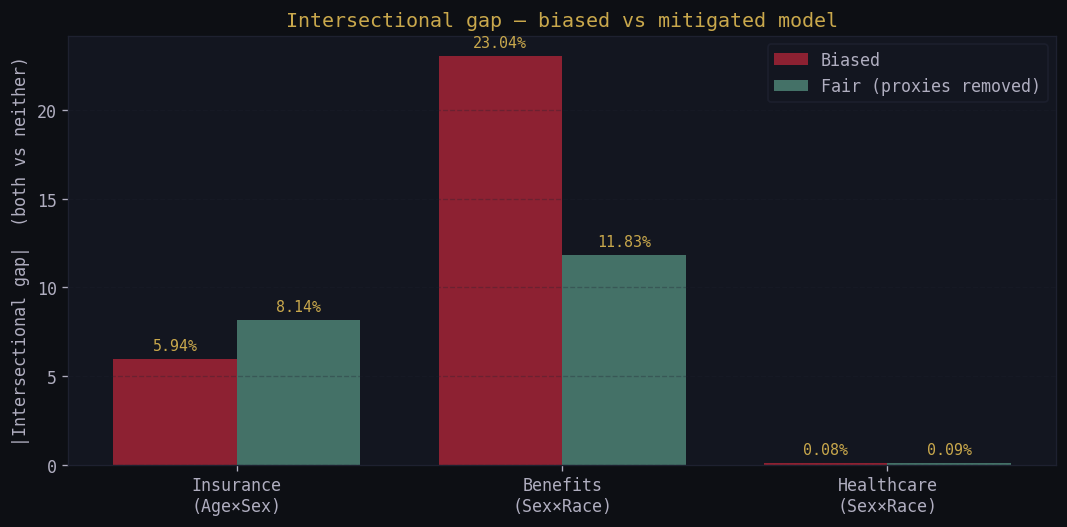

In [6]:
audits = ['Insurance\n(Age×Sex)', 'Benefits\n(Sex×Race)', 'Healthcare\n(Sex×Race)']
inter_biased = [abs(rep_ins_biased['intersectional']['gap']),
                abs(rep_ben_biased['intersectional']['gap']),
                abs(rep_hc_biased['intersectional']['gap'])]
inter_fair   = [abs(rep_ins_fair['intersectional']['gap']),
                abs(rep_ben_fair['intersectional']['gap']),
                abs(rep_hc_fair['intersectional']['gap'])]

x = np.arange(len(audits))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, [v * 100 for v in inter_biased], w, label='Biased', color=DANGER, alpha=0.9)
b2 = ax.bar(x + w/2, [v * 100 for v in inter_fair],   w, label='Fair (proxies removed)', color=SAFE, alpha=0.9)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02 * max(inter_biased) * 100 + 0.05,
                f'{h:.2f}%', ha='center', color=ACCENT, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(audits)
ax.set_ylabel('|Intersectional gap|  (both vs neither)')
ax.set_title('Intersectional gap — biased vs mitigated model', color=ACCENT, fontsize=12)
ax.legend(facecolor='#131620', edgecolor='#1e2130', labelcolor=MUTED)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Marginal vs intersectional, and whether superadditivity survives mitigation
print(f"{'Audit':<26}{'inter gap':>12}{'marg sum':>12}{'superadd?':>11}{'signif?':>9}")
print('-' * 70)
for name, b, f in [('Insurance  biased', ins_b, None), ('Insurance  fair', ins_f, None),
                   ('Benefits   biased', ben_b, None), ('Benefits   fair', ben_f, None),
                   ('Healthcare biased', hc_b, None), ('Healthcare fair', hc_f, None)]:
    print(f"{name:<26}{b['gap']:>11.2%}{b['marg_sum']:>12.2%}"
          f"{('yes' if b['superadditive'] else 'no'):>11}"
          f"{('yes' if b['significant'] else 'no'):>9}")

Audit                        inter gap    marg sum  superadd?  signif?
----------------------------------------------------------------------
Insurance  biased              -5.94%      13.37%         no       no
Insurance  fair                -8.14%       4.71%        yes       no
Benefits   biased             -23.04%      30.75%         no      yes
Benefits   fair               -11.83%      15.42%         no      yes
Healthcare biased              -0.08%       0.10%         no       no
Healthcare fair                -0.09%       0.10%         no       no


## Key Insight

Removing protected attributes and their proxies shrinks the *marginal* gaps — that is what the six single-axis audits were built to show. But the intersection does not always follow the marginals down.

In **Benefits Denial** and **Healthcare Readmission**, proxy removal shrinks the compounded gap roughly in step with the marginals, and neither the biased nor the fair model is superadditive: the two disadvantages stack, but they do not amplify each other. That is the reassuring case — a single-axis audit was not badly misleading.

**Insurance Denial** is the cautionary one. After proxy removal the marginal age and sex gaps shrink substantially, and their sum drops from ~13% to under 5% — yet the compounded gap for young women does *not* fall with them, and the fair model crosses into **superadditive** territory (the intersectional gap now exceeds the sum of the two shrunken marginals). A team reading only the marginal numbers from `fair.py` would see them collapsing and conclude the model was fixed, while the smallest cell holds a gap the marginals have stopped reporting — exactly Crenshaw's point, reproduced by a Random Forest instead of a courtroom. The honest qualifier: that Insurance intersectional gap is **not statistically significant** (the young-women cell is only ~44 patients, so the CI is wide), so it is a flag to investigate with more data, not a proven harm. The superadditive *pattern*, not the specific magnitude, is what a marginal-only audit could never surface.

Two caveats keep this honest. First, the doubly-disadvantaged cell is always the smallest of the four quadrants, so its gap carries the widest confidence interval and is the quickest to trip the small-sample warning — read the CI and the `n`, not just the point estimate. Second, an intersectional gap that is not statistically significant (as several here are, especially in the rare-event readmission data) is a "not enough evidence" result, not a clean bill of health. Intersectional auditing does not replace the marginal audit; it catches the harm the marginal audit is structurally unable to see.

---

### Further reading

- Crenshaw, K. (1989). *Demarginalizing the Intersection of Race and Sex: A Black Feminist Critique of Antidiscrimination Doctrine, Feminist Theory and Antiracist Politics.* University of Chicago Legal Forum, 1989(1), 139–167.
- Buolamwini, J. & Gebru, T. (2018). *Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification.* Proceedings of Machine Learning Research, 81, 1–15.
- Related in this repo: [proxy-variables.md](../explainers/proxy-variables.md), [demographic-parity.md](../explainers/demographic-parity.md), and the single-axis audits this notebook builds on ([04](04_insurance_denial_bias_audit.ipynb), [05](05_benefits_denial_bias_audit.ipynb), [06](06_healthcare_readmission_bias_audit.ipynb)).
